# Metric Evaluation: WNBA Salary Valuation

## Notebook Outline

1. Load the same merged modeling dataset from the `assessing_learnability_multiyear` notebook
2. Reuse the baseline model setup
3. Define KPI-aligned evaluation metrics
4. Evaluate baseline models using RMSE and MAPE
5. Compare Dummy, Linear Regression, and Random Forest performance using RMSE
6. Visualize cross-validated RMSE results
7. Explain how CPWS fits as a team-level business KPI
8. Summarize baseline evaluation findings, MAPE instability, and leakage limitations

In [2]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

Note: `cross_validate` is added to support evaluating multiple metrics (RMSE, MAPE) in the same cross-validation loop.

## 1. Load Data

We use the same merged multi-year dataset from the `assessing_learnability_multiyear` notebook.

In [3]:
# Load and integrate data
repo = Path.cwd().parent
data_dir = repo / "data" / "raw"
years = list(range(2021, 2026))

# Load raw CSV components
raw = {}
for year in years:
    raw[year] = {
        "advanced": pd.read_csv(data_dir / f"{year}_advanced.csv"),
        "per_game": pd.read_csv(data_dir / f"{year}_per_game.csv"),
        "totals": pd.read_csv(data_dir / f"{year}_totals.csv"),
        "salary": pd.read_csv(data_dir / f"salary_{year}.csv"),
        "team_advanced": pd.read_csv(data_dir / f"{year}_advanced-team.csv"),
        "standings": pd.read_csv(data_dir / f"{year}_wnba_standings.csv"),
    }

for year, files in raw.items():
    print(f"\n{year}")
    for name, df in files.items():
        print(f"{name}: {df.shape}")


2021
advanced: (155, 24)
per_game: (155, 27)
totals: (155, 26)
salary: (191, 27)
team_advanced: (12, 27)
standings: (12, 5)

2022
advanced: (166, 24)
per_game: (166, 27)
totals: (166, 26)
salary: (202, 27)
team_advanced: (12, 27)
standings: (12, 5)

2023
advanced: (156, 24)
per_game: (156, 27)
totals: (156, 26)
salary: (184, 27)
team_advanced: (12, 27)
standings: (12, 5)

2024
advanced: (157, 24)
per_game: (157, 27)
totals: (157, 26)
salary: (180, 27)
team_advanced: (12, 27)
standings: (12, 5)

2025
advanced: (182, 24)
per_game: (182, 27)
totals: (182, 26)
salary: (227, 27)
team_advanced: (13, 27)
standings: (13, 5)


## Basic Cleaning

Before merging the datasets, we standardize column names and clean simple text values by removing year prefixes, replacing spaces and symbols with underscores, and changing `%` to `pct`. We converted blank or invalid entries to missing values (`nan`), and changed salary into a numeric column for later analysis

In [4]:
# Standardize column names into a code-friendly format
def clean_col(name):
    text = str(name).strip().lower()
    text = re.sub(r"20\d{2}\s+salary", "salary", text)
    text = re.sub(r"20\d{2}\s+signing", "signing", text)
    text = text.replace("%", "pct")

    # Replace spaces and symbols with underscores
    text = re.sub(r"[^0-9a-z]+", "_", text)
    text = text.strip("_")
    return text

# Apply basic cleaning to one dataframe
def clean_df(df):
    df = df.copy()

    # Apply the same column-name format to each dataset
    df.columns = [clean_col(col) for col in df.columns]

    # Clean text columns by removing extra spaces and standardizing missing values
    for col in df.select_dtypes(include=["object", "string"]).columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"": np.nan, "—": np.nan, "nan": np.nan})

    return df

cleaned = {}
for year, files in raw.items():
    cleaned[year] = {name: clean_df(df) for name, df in files.items()}
    cleaned[year]["salary"]["salary"] = pd.to_numeric(
        cleaned[year]["salary"]["salary"],
        errors="coerce"
    )

## Final Data Merge and Name Matching

Now, we create the final modeling dataframe by merging player salary, player production, and team-level context for each season.

This step follows the same merge and name-matching logic from the `assessing_learnability_multiyear` notebook, so the metric evaluation uses the same baseline modeling dataset. We manually fixes player-name encoding and spelling mismatches, then re-checks unmatched players before merging salary and performance data. For example, We identify "Azura Stevens": "Azura Stevens","Azurá Stevens": "Azura Stevens".

In [5]:
# Map full team names from team-level files to the abbreviations used in player-level files
teammap = {
    "Atlanta Dream": "ATL",
    "Chicago Sky": "CHI",
    "Connecticut Sun": "CON",
    "Dallas Wings": "DAL",
    "Golden State Valkyries": "GSV",
    "Indiana Fever": "IND",
    "Las Vegas Aces": "LVA",
    "Los Angeles Sparks": "LAS",
    "Minnesota Lynx": "MIN",
    "New York Liberty": "NYL",
    "Phoenix Mercury": "PHO",
    "Seattle Storm": "SEA",
    "Washington Mystics": "WAS",
}

def team_clean(val):
    if pd.isna(val):
        return np.nan

    # Basketball Reference marks some teams with "*"; remove it before mapping
    return str(val).replace("*", "").strip()

season_parts = {}

for year in years:
    adv = cleaned[year]["advanced"]
    per = cleaned[year]["per_game"]
    tot = cleaned[year]["totals"]
    sal = cleaned[year]["salary"].copy()
    teamadv = cleaned[year]["team_advanced"].copy()
    stand = cleaned[year]["standings"].copy()

    # Standardize team names so team-level data can merge with player-level data
    teamadv["team_name"] = teamadv["team"].map(team_clean)
    teamadv["team"] = teamadv["team_name"].map(teammap)
    stand["team_name"] = stand["team_name"].map(team_clean)
    stand["team"] = stand["team_name"].map(teammap)

    # Combine team advanced stats with standings data
    teamdf = teamadv.merge(stand, on=["team", "team_name"], how="left", suffixes=("_adv", "_stand"))

    # Merge per_game and advanced player stats into one production dataframe
    playerdf = per.merge(adv, on=["player", "team", "pos", "g", "mp"], how="outer", suffixes=("_per", "_adv"))
    # Add total count stats to the same player production dataframe.
    playerdf = playerdf.merge(tot, on=["player", "team", "pos", "g", "mp", "gs"], how="outer", suffixes=("", "_tot"))

    # Check player name mismatches before creating final_df
    salary_only = sal[~sal["player"].isin(playerdf["player"])]
    stats_only = playerdf[~playerdf["player"].isin(sal["player"])]

    print(f"\n{year} Before name fixes")
    print("Salary only players:")
    print(sorted(salary_only["player"].dropna().unique()))

    print("\nStats only players:")
    print(sorted(stats_only["player"].dropna().unique()))

    # Save the season-level intermediate dataframes so they can be reused
    season_parts[year] = {
        "sal": sal,
        "playerdf": playerdf,
        "teamdf": teamdf,
    }


2021 Before name fixes
Salary only players:
['Brittany Boyd-Jones', 'Jocelyn Willoughby', 'Maria Kliundikova', "N'Dea Jones", 'Rennia Davis']

Stats only players:
['Brittany Boyd']

2022 Before name fixes
Salary only players:
['Asia (AD) Durr', 'Brittney Griner', 'Kia Nurse']

Stats only players:
['AD Durr']

2023 Before name fixes
Salary only players:
['Asia (AD) Durr', 'Azurá Stevens', 'Christyn Williams', 'Diamond DeShields', 'Dorka Juhász', 'Isabelle Harrison', 'Ivana Dojkić', 'Katie Lou Samuelson', 'Lou Lopez Sénéchal', 'Natalie Achonwa', 'Riquna Williams', 'Sika Koné', 'Skylar Diggins']

Stats only players:
['AD Durr', 'Azura Stevens', 'Dorka JuhÃ¡sz', 'Ivana DojkiÄ\x87', 'Kadi Sissoko', 'Sika KonÃ©']

2024 Before name fixes
Salary only players:
['Dorka Juhász', 'Ivana Dojkić', 'Lou Lopez Sénéchal', 'Nika Mühl', 'Olivia Époupa', 'Sika Kone', 'Temi Fágbénlé']

Stats only players:
['Dorka JuhÃ¡sz', 'Ivana DojkiÄ\x87', 'Lou Lopez SÃ©nÃ©chal', 'Nika MÃ¼hl', 'Olivia Ã\x89poupa', 'Sik

In [6]:
# Manually fix clear name encoding/spelling mismatches across the 2021-2025 files
name_fix = {
    "AD Durr": "Asia (AD) Durr",
    "Anastasiia Kosu": "Anastasiia Olairi Kosu",
    "Azura Stevens": "Azura Stevens",
    "Azurá Stevens": "Azura Stevens",
    "Brittany Boyd": "Brittany Boyd-Jones",
    "Dorka JuhÃ¡sz": "Dorka Juhasz",
    "Dorka Juhász": "Dorka Juhasz",
    "Ivana DojkiÄ": "Ivana Dojkic",
    "Ivana Dojkić": "Ivana Dojkic",
    "Janelle SalaÃ¼n": "Janelle Salaun",
    "Janelle Salaün": "Janelle Salaun",
    "LeÃ¯la Lacan": "Leila Lacan",
    "Leïla Lacan": "Leila Lacan",
    "Lou Lopez SÃ©nÃ©chal": "Lou Lopez Senechal",
    "Lou Lopez Sénéchal": "Lou Lopez Senechal",
    "Luisa GeiselsÃ¶der": "Luisa Geiselsoder",
    "Luisa Geiselsöder": "Luisa Geiselsoder",
    "Mamignan TourÃ©": "Mamignan Toure",
    "Mamignan Touré": "Mamignan Toure",
    "MariÃ¨me Badiane": "Marieme Badiane",
    "Marième Badiane": "Marieme Badiane",
    "Nika MÃ¼hl": "Nika Muhl",
    "Nika Mühl": "Nika Muhl",
    "Olivia Ãpoupa": "Olivia Epoupa",
    "Olivia Époupa": "Olivia Epoupa",
    "Sika KonÃ©": "Sika Kone",
    "Sika Koné": "Sika Kone",
    "Te-Hina PaoPao": "Te-Hina Paopao",
    "Temi Fágbénlé": "Temi Fagbenle",
}

season_dfs = []

for year in years:
    # Retrieve the saved season-level dataframes for applying name fixes and final merging
    sal = season_parts[year]["sal"].copy()
    playerdf = season_parts[year]["playerdf"].copy()
    teamdf = season_parts[year]["teamdf"]

    # Apply the name corrections before merging salary and production data
    sal["player"] = sal["player"].replace(name_fix)
    playerdf["player"] = playerdf["player"].replace(name_fix)

    # Re-check after name fixes
    salary_only = sal[~sal["player"].isin(playerdf["player"])]
    stats_only = playerdf[~playerdf["player"].isin(sal["player"])]

    print(f"\n{year} After name fixes")
    print("Salary only players:")
    print(sorted(salary_only["player"].dropna().unique()))

    print("\nStats only players:")
    print(sorted(stats_only["player"].dropna().unique()))

    # seasondf = salary + player stats + team context + season column
    seasondf = sal.merge(playerdf, on="player", how="inner", suffixes=("_sal", ""))
    seasondf = seasondf.merge(teamdf, on="team", how="left", suffixes=("", "_team"))
    seasondf["season"] = year

    # season_dfs = [seasondf_2021, seasondf_2022, seasondf_2023, seasondf_2024, seasondf_2025]
    season_dfs.append(seasondf)

final_df = pd.concat(season_dfs, ignore_index=True)

print(final_df.shape)
final_df.head()


2021 After name fixes
Salary only players:
['Jocelyn Willoughby', 'Maria Kliundikova', "N'Dea Jones", 'Rennia Davis']

Stats only players:
[]

2022 After name fixes
Salary only players:
['Brittney Griner', 'Kia Nurse']

Stats only players:
[]

2023 After name fixes
Salary only players:
['Christyn Williams', 'Diamond DeShields', 'Isabelle Harrison', 'Katie Lou Samuelson', 'Lou Lopez Senechal', 'Natalie Achonwa', 'Riquna Williams', 'Skylar Diggins']

Stats only players:
['Kadi Sissoko']

2024 After name fixes
Salary only players:
[]

Stats only players:
[]

2025 After name fixes
Salary only players:
['Georgia Amoore', 'Katie Lou Samuelson']

Stats only players:
[]
(967, 124)


,player,salary,signing,g_sal,gs_sal,min,pts_sal,fgm,fga_sal,fgpct,...,opp_tov_pct,drb_pct,opp_ft_rate,arena_name,team_name,wins_stand,losses_stand,win_loss_pct,gb,season
0,Tina Charles,175000,UFA,27,27,33.3,23.4,8.8,19.6,44.9%,...,15.3,76.4,0.208,St. Elizabeths East Arena,Washington Mystics,12.0,20.0,0.375,14.0,2021
1,Brittney Griner,221450,NaN,30,30,32.8,20.5,8.3,14.4,57.5%,...,11.3,75.1,0.167,Phoenix Suns Arena,Phoenix Mercury,19.0,13.0,0.594,7.0,2021
2,Breanna Stewart,190550,NaN,28,28,33.3,20.3,6.9,15.8,43.9%,...,14.4,78.6,0.180,Angels of the Winds Arena,Seattle Storm,21.0,11.0,0.656,5.0,2021
3,Jonquel Jones,190550,NaN,27,27,31.7,19.4,7.1,13.8,51.5%,...,16.1,82.1,0.201,Mohegan Sun Arena,Connecticut Sun,26.0,6.0,0.813,NaN,2021
4,Arike Ogunbowale,58710,NaN,32,32,31.4,18.7,6.2,16.3,38.3%,...,14.1,77.6,0.206,College Park Center,Dallas Wings,14.0,18.0,0.438,12.0,2021


## 2. Baseline Model Setup

This section reuses the baseline modeling setup from the `assessing_learnability_multiyear` notebook.

The goal is not to build new models. Instead, we define the same feature matrix, target variable, preprocessing pipeline, baseline models, and cross-validation setup so that the metric evaluation is consistent with the `assessing_learnability_multiyear` notebook.

Setup:

- `x`: model input features
- `y`: target variable, salary
- Models: `DummyRegressor`, `LinearRegression`, and `RandomForestRegressor`
- Validation method: 5-fold cross-validation

For preprocessing, numeric missing values are filled with the median because the dataset is small and dropping rows would reduce the sample size. The median is also less sensitive to outliers than the mean. Categorical missing values are filled as `Unknown`, then converted with one-hot encoding so the models can use them. The `DummyRegressor` is used as the trivial baseline model.

In [7]:
# Drop target, identifiers, and empty placeholder columns before modeling
dropcols = {"salary", "player", "team_name", "arena_name", "dummy", "dummy_team"}
xcols = [col for col in final_df.columns if col not in dropcols]

# Keep only rows with salary, since salary is the regression target
modeldf = final_df.dropna(subset=["salary"]).copy()

x = modeldf[xcols]
y = modeldf["salary"]

# Split features by data type
numcols = x.select_dtypes(include=np.number).columns.tolist()
catcols = x.select_dtypes(exclude=np.number).columns.tolist()

# Numeric features: fill missing values with the median and scale the values
numpipe = Pipeline([
    ("fill", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

# Categorical features: mark missing values as Unknown, convert to string, and one-hot encode
catpipe = Pipeline([
    ("fill", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("to_string", FunctionTransformer(lambda data: data.astype(str))),
    ("code", OneHotEncoder(handle_unknown="ignore"))
])

# Apply preprocessing to numeric and categorical columns
preproc = ColumnTransformer([
    ("num", numpipe, numcols),
    ("cat", catpipe, catcols)
])

# Reuse the same baseline models from the learnability assessment notebook
models = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=5,
        random_state=26
    ),
}

# Use the same 5-fold cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=26)

print("x shape:", x.shape)
print("y shape:", y.shape)
print("numeric features:", len(numcols))
print("categorical features:", len(catcols))

x shape: (967, 118)
y shape: (967,)
numeric features: 92
categorical features: 26


Note: The `assessing_learnability_multiyear` notebook only used RMSE. In this metric evaluation notebook, we use a `scoring` dictionary so RMSE and MAPE can be evaluated in the same cross-validation loop. Thus, we remove `rmse = "neg_root_mean_squared_error"`.

## 3. Metric Evaluation

We evaluate each baseline model with 5-fold cross-validation using KPI-aligned metrics.

The primary predictive metric is RMSE. We also report MAPE because it measures prediction error relative to contract size according to `dataset_KPI_description.md`. Lower RMSE and lower MAPE indicate better model performance. We do not report CPWS (business ROI KPI) here since it is not a direct cross-validation scoring metric for player salary prediction.

In [8]:
# Define KPI-aligned scoring metrics
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mape": "neg_mean_absolute_percentage_error"
}

## 4. Cross-Validated Model Evaluation

Each baseline model is evaluated with 5-fold cross-validation. This step extends the previous RMSE-only comparison by adding MAPE as a second evaluation metric.

The table reports average RMSE and MAPE across validation folds. Since scikit-learn returns loss metrics as negative scores, we multiply by `-1` so the reported values are positive. For the MAPE part, values are multiplied by 100 so they can be interpreted as percentages.

In [ ]:
# This cell extends the learnability assessment's RMSE-only evaluation to include both RMSE and MAPE.
# Store cross-validation results for each model
rows = []

for name, mod in models.items():
    # Combine preprocessing and model so each fold is processed consistently
    pipe = Pipeline([
        ("prep", preproc),
        ("model", mod)
    ])

    scores = cross_validate(
        pipe,
        x,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False     # We only need test scores for the final evaluation, so skip train scores to save memory
    )

    rows.append({
        "model": name,
        "rmse_mean": -scores["test_rmse"].mean(),             #Lower RMSE is better
        "rmse_std": scores["test_rmse"].std(),                #larger values mean less stable performance across folds
        "mape_mean_pct": -scores["test_mape"].mean() * 100,   #Lower MAPE is better, and multiplying by 100 converts it to a percentage for easier interpretation
        "mape_std_pct": scores["test_mape"].std() * 100,      # Larger values mean MAPE is less stable across folds
        # Here, the scores dictionary contains the RMSE and MAPE for each fold, so we could also include fold-level results if desired. For example:
        #"rmse_fold_1": -scores["test_rmse"][0]
        #"mape_fold_1": -scores["test_mape"][0] * 100
    })

# Convert model results into a comparison table
metric_df = pd.DataFrame(rows)

# Use DummyRegressor as the baseline for both RMSE and MAPE improvement
base_rmse = metric_df.loc[
    metric_df["model"].eq("DummyRegressor"),
    "rmse_mean"
].iloc[0]

base_mape = metric_df.loc[
    metric_df["model"].eq("DummyRegressor"),
    "mape_mean_pct"
].iloc[0]

# Positive values mean the model improves over the dummy baseline in terms of RMSE reduction
metric_df["rmse_gain_vs_dummy"] = base_rmse - metric_df["rmse_mean"]

# Positive values mean the model improves over the dummy baseline in terms of MAPE reduction
metric_df["mape_gain_vs_dummy"] = base_mape - metric_df["mape_mean_pct"]

# Sort by average RMSE so the best model appears first
metric_df.sort_values("rmse_mean")

,model,rmse_mean,rmse_std,mape_mean_pct,mape_std_pct,rmse_gain_vs_dummy,mape_gain_vs_dummy
2,RandomForestRegressor,39807.932398,2454.587042,2.543665e+19,3.122385e+19,28338.280573,5.404479e+19
1,LinearRegression,55170.422260,5008.905946,2.132513e+19,2.687487e+19,12975.790710,5.815631e+19
0,DummyRegressor,68146.212970,2633.331335,7.948144e+19,9.735216e+19,0.000000,0.000000e+00


In [10]:
# Diagnostic check for MAPE instability
print("Minimum salary:", y.min())
print("Number of zero salaries:", (y == 0).sum())
print("Number of salaries below 1000:", (y < 1000).sum())
print("Number of salaries below 10000:", (y < 10000).sum())
print("Number of salaries below 66000:", (y < 66000).sum())

y[y < 66000].sort_values().head(20)

Minimum salary: 0
Number of zero salaries: 2
Number of salaries below 1000: 7
Number of salaries below 10000: 141
Number of salaries below 66000: 394


735       0
828       0
144     464
734     635
701     635
880     833
384     898
161    1106
532    1219
500    1219
960    1250
687    1270
373    1347
178    1391
184    1391
556    1454
689    1516
276    1607
305    1607
562    1625
Name: salary, dtype: int64

### MAPE Diagnostic Note
The full-sample MAPE values are extremely large, by definition of MAPE, when we have low-valued numerical data, we will then have a large MAPE value. Thus, the result coincide with the math part.

In this dataset, there are 2 zero salary observations and 394 observations below 66,000. This suggests that rookie-scale, hardship, or otherwise non-standard salary observations may distort the percentage-based metric.

For this baseline evaluation, RMSE should be treated as the main comparison metric. MAPE is still reported because it is listed as a secondary KPI, but it should be interpreted carefully. **A later evaluation pipeline should consider separating contract types or applying a salary floor before using MAPE as a decision metric.**

## 5. Metric Visualization

Because MAPE is unstable in the full-sample evaluation, the main visualization focuses on RMSE, the primary predictive KPI.

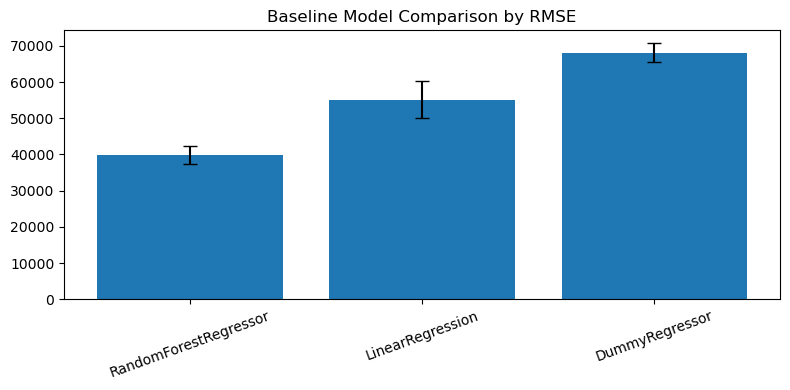

In [18]:
plot_df = metric_df.sort_values("rmse_mean")
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(plot_df["model"], plot_df["rmse_mean"], yerr=plot_df["rmse_std"], capsize=5)
ax.set_label("Cross-validated RMSE")
ax.set_title("Baseline Model Comparison by RMSE")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 6. CPWS as a Team-Level Business KPI
The `dataset_KPI_description.md` defines CPWS as the business ROI metric: `CPWS = Total Team Payroll / Total Season Win Shares`

This metric is designed to evaluate franchise-level spending efficiency. RMSE and MAPE evaluate individual salary prediction. CPWS is different because it is a team-level business metric. It connects the salary prediction task to the broader project goal of evaluating franchise ROI.

In this notebook, CPWS is not included in the cross-validation scoring loop because the baseline models predict individual player salary, not team-level payroll efficiency directly. **A later results pipeline can calculate CPWS after predicted salaries are aggregated by team and season.**

## 7. Summary and Limitations

This metric evaluation notebook compares baseline salary prediction models using KPI-aligned metrics from `dataset_KPI_description.md` notebook.

RMSE is treated as the primary predictive KPI because it measures the difference between predicted and actual salaries and penalizes large salary errors more heavily. Based on RMSE, both `LinearRegression` and `RandomForestRegressor` improve over the `DummyRegressor` baseline. The `RandomForestRegressor` has the lowest average RMSE in this baseline evaluation.

MAPE is included as the secondary fairness KPI here because it measures prediction error relative to contract size. However, since MAPE divides by actual salary, very small salary values can produce extremely large percentage errors.

CPWS is documented as the business ROI KPI, but it is not directly calculated inside the cross-validation scoring loop. It should be evaluated later at the team-season level after player salary predictions are aggregated into team payroll estimates.

Overall, the baseline results suggest that player production, team context, and season information contain useful signal for salary prediction. We omit this part in this notebook, but it can be found in the second part of `assessing_learnability_multiyear.ipynb` notebook.

**However, this notebook still has important limitations:**
 - MAPE is unstable in the full-sample evaluation because of zero and very low salary observations. Future evaluation should consider contract-type separation or salary floors before relying on percentage-based metrics. 
 - This notebook uses the same 5-fold cross-validation setup from the learnability assessment notebook. The final evaluation pipeline should later be aligned with `splitting.ipynb` notebook to reduce temporal, group-level, and post-outcome leakage risks.